<a href="https://colab.research.google.com/github/rainygold25/SkinCancerDetectorHackathon/blob/main/SkinSight_CNN_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SkinSight CNN — re-implemented in PyTorch

The original SkinSight study trained a 3-layer convolutional network in **TensorFlow / Keras** and reported a **73.58% mean test accuracy over 3 trials**. This notebook rebuilds that same network in **PyTorch** and repeats the same protocol, so the two frameworks can be compared like for like.

**Same protocol as the original**

| Setting | Value |
|---|---|
| Image size | 244 × 244 |
| Pixel scaling | divide by 255 |
| Model | 3 Conv2D + 2 MaxPooling + Flatten + 2 Dense (ReLU) |
| Batch size | 32 |
| Epochs | 50 |
| Trials | 3 |

**How to run**

1. `Runtime → Change runtime type → GPU`.
2. Put your dataset in Google Drive with one sub-folder per class inside a `Train` folder and a `Test` folder.
3. Set the two paths in the **Configuration** cell.
4. `Runtime → Run all`.

If the dataset folders are not found, the notebook switches to **demo mode** and trains on small synthetic images, only to prove the code runs. Demo numbers mean nothing.

## 1. Setup

In [1]:
import os, json, random, shutil, tempfile, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

def set_seed(seed):
    # Same seed -> same weight initialisation and same shuffling order.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

PyTorch 2.11.0+cu130 | device: cuda


## 2. Configuration

Change only this cell. For a first run, set `EPOCHS = 5` to check everything works, then put it back to 50.

In [2]:
# Folders in Google Drive. Each must contain one sub-folder per class.
TRAIN_DIR = "/content/drive/MyDrive/Skin Cancer Dataset/Train"
TEST_DIR  = "/content/drive/MyDrive/Skin Cancer Dataset/Test"

# Use only these class folders (the study used four diagnostic classes).
# Leave as None to use every folder found in TRAIN_DIR.
CLASSES = None      # example: ["melanoma", "nevus", "basal cell carcinoma", "actinic keratosis"]

IMG_SIZE      = 244     # the original used 244 x 244
BATCH_SIZE    = 32
EPOCHS        = 50
TRIALS        = 3
LEARNING_RATE = 1e-3    # Adam's default, the same default Keras uses

COPY_TO_LOCAL = True    # copy the dataset from Drive to the Colab disk first (much faster reads)
KERAS_MEAN_ACC = 73.58  # original TensorFlow / Keras result, % mean over 3 trials

## 3. Data

In [4]:
# Mount Google Drive when running in Colab.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as e:
    print(f"Could not mount Google Drive ({type(e).__name__}: {e}). Proceeding without Drive.")
    IN_COLAB = False


def make_demo_dataset(root, classes=4, n_train=24, n_test=8, size=IMG_SIZE):
    # Tiny synthetic dataset: each class is noise plus a blob in its own position and colour.
    from PIL import Image
    rng = np.random.default_rng(0)
    for split, n in (("Train", n_train), ("Test", n_test)):
        for c in range(classes):
            folder = os.path.join(root, split, f"class_{c}")
            os.makedirs(folder, exist_ok=True)
            for i in range(n):
                img = rng.integers(90, 160, size=(size, size, 3), dtype=np.uint8)
                cx = size // 4 + (c % 2) * size // 2 + int(rng.integers(-10, 10))
                cy = size // 4 + (c // 2) * size // 2 + int(rng.integers(-10, 10))
                r = size // 8
                yy, xx = np.ogrid[:size, :size]
                mask = (xx - cx) ** 2 + (yy - cy) ** 2 < r * r
                colour = [(200, 60, 60), (60, 200, 60), (60, 60, 200), (200, 200, 60)][c % 4]
                img[mask] = colour
                Image.fromarray(img).save(os.path.join(folder, f"{i}.png"))
    return os.path.join(root, "Train"), os.path.join(root, "Test")


DEMO_MODE = not (os.path.isdir(TRAIN_DIR) and os.path.isdir(TEST_DIR))
if DEMO_MODE:
    print("Dataset folders not found -> DEMO MODE (synthetic images). Results are NOT real.")
    TRAIN_DIR, TEST_DIR = make_demo_dataset(tempfile.mkdtemp(prefix="skinsight_demo_"))
    CLASSES = None
elif COPY_TO_LOCAL and IN_COLAB:
    local_root = "/content/skin_data"
    for name, src in (("Train", TRAIN_DIR), ("Test", TEST_DIR)):
        dst = os.path.join(local_root, name)
        if not os.path.isdir(dst):
            print("Copying", src, "->", dst)
            shutil.copytree(src, dst)
    TRAIN_DIR, TEST_DIR = os.path.join(local_root, "Train"), os.path.join(local_root, "Test")

print("Train folder:", TRAIN_DIR)
print("Test folder: ", TEST_DIR)

Could not mount Google Drive (MessageError: Error: credential propagation was unsuccessful). Proceeding without Drive.
Dataset folders not found -> DEMO MODE (synthetic images). Results are NOT real.
Train folder: /tmp/skinsight_demo__48lepsf/Train
Test folder:  /tmp/skinsight_demo__48lepsf/Test


In [6]:
class SubsetImageFolder(datasets.ImageFolder):
    # ImageFolder that can be limited to a chosen list of class folders.
    def __init__(self, root, keep=None, **kwargs):
        self._keep = keep
        super().__init__(root, **kwargs)

    def find_classes(self, directory):
        classes, class_to_idx = super().find_classes(directory)
        # Ignore hidden folders such as .ipynb_checkpoints that Colab can create.
        classes = [c for c in classes if not c.startswith(".")]
        class_to_idx = {c: i for i, c in enumerate(classes)}
        if self._keep:
            missing = [c for c in self._keep if c not in classes]
            if missing:
                raise FileNotFoundError(f"Class folders not found in {directory}: {missing}. Found: {classes}")
            classes = sorted(self._keep)
            class_to_idx = {c: i for i, c in enumerate(classes)}
        return classes, class_to_idx


# Resize + ToTensor. ToTensor converts 0-255 pixels to 0-1 floats,
# which is the same as the Keras ImageDataGenerator(rescale=1/255).
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = SubsetImageFolder(TRAIN_DIR, keep=CLASSES, transform=tfm)
test_ds  = SubsetImageFolder(TEST_DIR,  keep=CLASSES, transform=tfm)
assert train_ds.classes == test_ds.classes, "Train and Test must have the same class folders"

class_names = train_ds.classes
num_classes = len(class_names)
workers = 2 if IN_COLAB else 0
pin = device.type == "cuda"

def make_loaders(seed):
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g,
                              num_workers=workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=workers, pin_memory=pin)
    return train_loader, test_loader

print(f"{num_classes} classes: {class_names}")
for name, ds in (("train", train_ds), ("test", test_ds)):
    counts = np.bincount(ds.targets, minlength=num_classes)
    print(f"{name:5s} {len(ds):5d} images | per class: {dict(zip(class_names, counts.tolist()))}")

4 classes: ['class_0', 'class_1', 'class_2', 'class_3']
train    96 images | per class: {'class_0': 24, 'class_1': 24, 'class_2': 24, 'class_3': 24}
test     32 images | per class: {'class_0': 8, 'class_1': 8, 'class_2': 8, 'class_3': 8}


## 4. Model

The same layers as the Keras model, written as a PyTorch `nn.Module`.

| Keras | PyTorch |
|---|---|
| `Conv2D(32, 3, activation="relu")` | `nn.Conv2d(3, 32, 3)` then `nn.ReLU()` |
| `MaxPooling2D()` | `nn.MaxPool2d(2)` |
| `Flatten()` | `nn.Flatten()` |
| `Dense(64, activation="relu")` | `nn.Linear(n, 64)` then `nn.ReLU()` |
| `Dense(classes, activation="softmax")` + `categorical_crossentropy` | `nn.Linear(64, classes)` + `nn.CrossEntropyLoss()` |

Two differences are worth knowing:

- **No softmax layer.** `nn.CrossEntropyLoss` applies log-softmax itself, so the model outputs raw scores (logits).
- **Input size is explicit.** Keras infers the size after `Flatten()`. In PyTorch the first `Linear` layer needs it, so the model measures it once with a dummy image.

The filter counts (32, 64, 64) and the 64-unit dense layer are common defaults. If your original notebook used different numbers, change them here so the two models match.

In [7]:
class SkinCNN(nn.Module):
    def __init__(self, num_classes, img_size=IMG_SIZE):
        super().__init__()
        # 3 convolution layers, 2 max-pooling layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3), nn.ReLU(),
        )
        # Measure the flattened size with one dummy image.
        with torch.no_grad():
            n_flat = self.features(torch.zeros(1, 3, img_size, img_size)).flatten(1).shape[1]
        # Flatten + 2 dense layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_flat, 64), nn.ReLU(),
            nn.Linear(64, num_classes),      # raw scores (logits); no softmax here
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = SkinCNN(num_classes)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")

SkinCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=207936, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Trainable parameters: 13,364,548


## 5. Training loop

Keras hides this inside `model.fit()`. In PyTorch you write it: forward pass, loss, backward pass, optimizer step.

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    # One pass over the data. With an optimizer it trains; without one it only evaluates.
    training = optimizer is not None
    model.train(training)
    total_loss, correct, seen = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)                 # forward pass
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad()              # clear old gradients
                loss.backward()                    # backward pass
                optimizer.step()                   # update weights
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            seen += images.size(0)
    return total_loss / seen, correct / seen


def train_trial(seed):
    set_seed(seed)
    train_loader, test_loader = make_loaders(seed)
    model = SkinCNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    hist = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start = time.time()
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        te_loss, te_acc = run_epoch(model, test_loader, criterion)
        for k, v in zip(hist, (tr_loss, tr_acc, te_loss, te_acc)):
            hist[k].append(v)
        print(f"  epoch {epoch:3d}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.3f} "
              f"| test loss {te_loss:.4f} acc {te_acc:.3f}")
    hist["seconds"] = time.time() - start
    return model, hist, test_loader

## 6. Run the trials

Each trial starts from a different random seed, as in the original study. The headline number is the **test accuracy after the final epoch**, averaged over the trials.

In [9]:
histories, models = [], []
for t in range(TRIALS):
    print(f"Trial {t + 1} of {TRIALS}")
    model, hist, test_loader = train_trial(seed=t)
    histories.append(hist)
    models.append(model)

Trial 1 of 3
  epoch   1/50 | train loss 3.0054 acc 0.271 | test loss 1.5146 acc 0.250
  epoch   2/50 | train loss 1.4893 acc 0.219 | test loss 1.3707 acc 0.250
  epoch   3/50 | train loss 1.4170 acc 0.292 | test loss 1.2874 acc 0.500
  epoch   4/50 | train loss 1.2786 acc 0.490 | test loss 1.1517 acc 0.750
  epoch   5/50 | train loss 1.1404 acc 0.708 | test loss 0.9691 acc 0.750
  epoch   6/50 | train loss 0.8109 acc 0.917 | test loss 0.5501 acc 1.000
  epoch   7/50 | train loss 0.4037 acc 1.000 | test loss 0.1673 acc 1.000
  epoch   8/50 | train loss 0.1148 acc 1.000 | test loss 0.0173 acc 1.000
  epoch   9/50 | train loss 0.0114 acc 1.000 | test loss 0.0068 acc 1.000
  epoch  10/50 | train loss 0.0031 acc 1.000 | test loss 0.0001 acc 1.000
  epoch  11/50 | train loss 0.0001 acc 1.000 | test loss 0.0000 acc 1.000
  epoch  12/50 | train loss 0.0000 acc 1.000 | test loss 0.0000 acc 1.000
  epoch  13/50 | train loss 0.0001 acc 1.000 | test loss 0.0002 acc 1.000
  epoch  14/50 | train lo

## 7. Results

In [10]:
final_acc = [100 * h["test_acc"][-1] for h in histories]
best_epoch = [int(np.argmin(h["test_loss"])) + 1 for h in histories]
acc_at_best = [100 * h["test_acc"][e - 1] for h, e in zip(histories, best_epoch)]

print(f"{'Trial':>5} | {'Final test acc':>14} | {'Lowest-test-loss epoch':>22} | {'Acc at that epoch':>17}")
for t in range(TRIALS):
    print(f"{t + 1:>5} | {final_acc[t]:>13.2f}% | {best_epoch[t]:>22d} | {acc_at_best[t]:>16.2f}%")

mean_acc, std_acc = float(np.mean(final_acc)), float(np.std(final_acc))
print()
print(f"PyTorch mean test accuracy over {TRIALS} trials: {mean_acc:.2f}% (std {std_acc:.2f})")
if DEMO_MODE:
    print("DEMO MODE: synthetic data, so this number is not comparable with the study.")
else:
    print(f"Original Keras mean test accuracy:            {KERAS_MEAN_ACC:.2f}%")
    print(f"Difference (PyTorch - Keras):                 {mean_acc - KERAS_MEAN_ACC:+.2f} points")

Trial | Final test acc | Lowest-test-loss epoch | Acc at that epoch
    1 |        100.00% |                     22 |           100.00%
    2 |        100.00% |                     47 |           100.00%
    3 |        100.00% |                     15 |           100.00%

PyTorch mean test accuracy over 3 trials: 100.00% (std 0.00)
DEMO MODE: synthetic data, so this number is not comparable with the study.


### Training curves

Training loss keeps falling, so it cannot tell you when to stop. Test loss falls and then rises once the model starts to overfit; the dashed line marks the epoch where it was lowest. This is the same reading the SkinSight study used to choose the number of epochs.

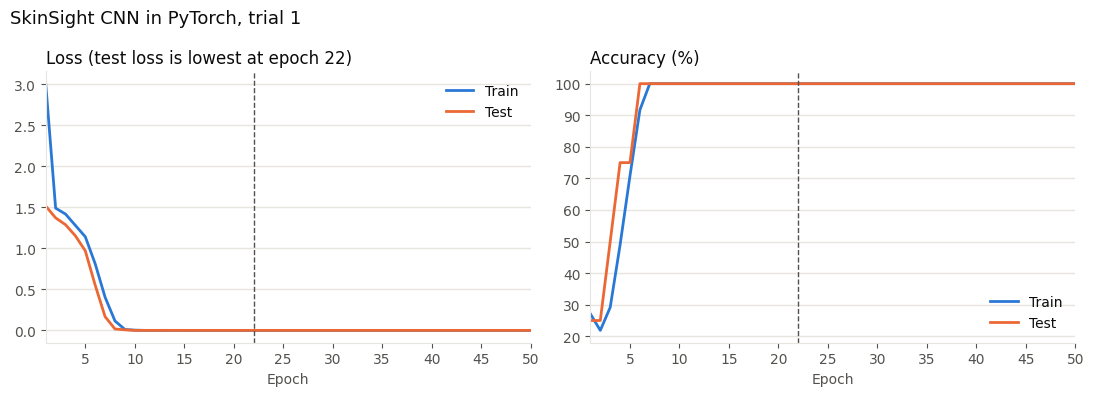

In [11]:
TRIAL_TO_PLOT = 0          # which trial to draw (0 = first)
C_TRAIN, C_TEST = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

h = histories[TRIAL_TO_PLOT]
epochs = np.arange(1, EPOCHS + 1)
best = best_epoch[TRIAL_TO_PLOT]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor="white")
panels = [(f"Loss (test loss is lowest at epoch {best})", "train_loss", "test_loss", 1.0),
          ("Accuracy (%)", "train_acc", "test_acc", 100.0)]
for ax, (title, k_train, k_test, scale) in zip(axes, panels):
    y_train, y_test = np.array(h[k_train]) * scale, np.array(h[k_test]) * scale
    ax.plot(epochs, y_train, color=C_TRAIN, linewidth=2, label="Train")
    ax.plot(epochs, y_test, color=C_TEST, linewidth=2, label="Test")
    ax.axvline(best, color=MUTED, linewidth=1, linestyle="--")
    ax.set_title(title, loc="left", fontsize=12, color=INK)
    ax.set_xlabel("Epoch", color=MUTED)
    ax.set_xlim(1, max(EPOCHS, 2))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED)
    ax.legend(frameon=False, labelcolor=INK)
fig.suptitle(f"SkinSight CNN in PyTorch, trial {TRIAL_TO_PLOT + 1}", x=0.01, ha="left", fontsize=13, color=INK)
fig.tight_layout()
fig.savefig("training_curves.png", dpi=150)
plt.show()

### Which classes get confused

Accuracy alone hides the errors that matter. For a cancer screen, a missed cancer (a false negative) is worse than a false alarm, so look at **recall per class**: of the real cases of each class, how many did the model find?

              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000         8
     class_1      1.000     1.000     1.000         8
     class_2      1.000     1.000     1.000         8
     class_3      1.000     1.000     1.000         8

    accuracy                          1.000        32
   macro avg      1.000     1.000     1.000        32
weighted avg      1.000     1.000     1.000        32



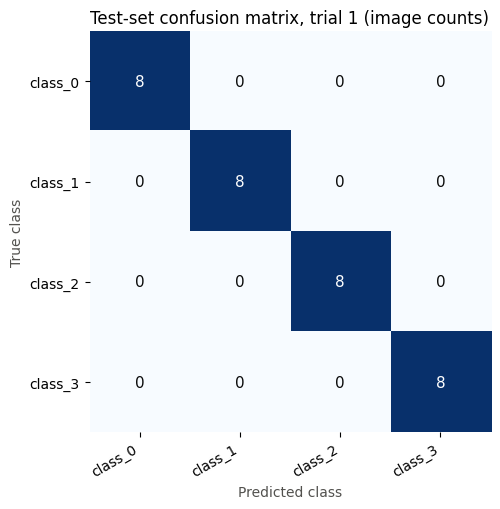

In [12]:
model = models[TRIAL_TO_PLOT].eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        y_pred.extend(model(images.to(device)).argmax(dim=1).cpu().tolist())
        y_true.extend(labels.tolist())

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print(classification_report(y_true, y_pred, labels=list(range(num_classes)),
                            target_names=class_names, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(1.6 + 1.1 * num_classes, 1.2 + 1.0 * num_classes), facecolor="white")
ax.imshow(cm, cmap="Blues", vmin=0)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() / 2 else "#0b0b0b")
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_yticks(range(num_classes))
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class", color="#52514e")
ax.set_ylabel("True class", color="#52514e")
ax.set_title(f"Test-set confusion matrix, trial {TRIAL_TO_PLOT + 1} (image counts)", loc="left", fontsize=12)
for side in ax.spines.values():
    side.set_visible(False)
fig.tight_layout()
fig.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 8. Save the model and the results

In [13]:
torch.save(models[TRIAL_TO_PLOT].state_dict(), "skinsight_cnn_pytorch.pt")

results = {
    "framework": f"PyTorch {torch.__version__}",
    "demo_mode": DEMO_MODE,
    "classes": class_names,
    "train_images": len(train_ds),
    "test_images": len(test_ds),
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "trials": TRIALS,
    "parameters": n_params,
    "final_test_acc_per_trial_pct": [round(a, 2) for a in final_acc],
    "mean_test_acc_pct": round(mean_acc, 2),
    "std_test_acc_pct": round(std_acc, 2),
    "lowest_test_loss_epoch_per_trial": best_epoch,
    "keras_mean_test_acc_pct": KERAS_MEAN_ACC,
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "framework": "PyTorch 2.11.0+cu130",
  "demo_mode": true,
  "classes": [
    "class_0",
    "class_1",
    "class_2",
    "class_3"
  ],
  "train_images": 96,
  "test_images": 32,
  "img_size": 244,
  "batch_size": 32,
  "epochs": 50,
  "trials": 3,
  "parameters": 13364548,
  "final_test_acc_per_trial_pct": [
    100.0,
    100.0,
    100.0
  ],
  "mean_test_acc_pct": 100.0,
  "std_test_acc_pct": 0.0,
  "lowest_test_loss_epoch_per_trial": [
    22,
    47,
    15
  ],
  "keras_mean_test_acc_pct": 73.58
}


## 9. Notes and limits

- **Test set used for monitoring.** Like the original study, this notebook watches the test set during training. That keeps the comparison like for like, but it means the "lowest test loss" epoch is chosen with knowledge of the test set. A cleaner design holds out a separate validation split from the training data and touches the test set once.
- **Same data, same protocol, different framework.** Small differences from the Keras number are expected: the two frameworks initialise weights differently and shuffle differently.
- **Class balance.** If one class has far more images than the others, accuracy flatters the model. Check the per-class recall above.

**My observations** *(write these after your run)*

- PyTorch mean accuracy vs the Keras 73.58%:
- Epoch where test loss was lowest, and what happened after it:
- Class the model confused most often:

## 10. Put it on GitHub

1. In Colab: `File → Save a copy in GitHub`, choose your repository (for example `SkinCancerDetectorHackathon`), and commit.
2. Download `results.json`, `training_curves.png` and `confusion_matrix.png` from the Colab file panel and add them to the same repository.
3. Add two lines to the repository README: what this notebook is, and your measured mean accuracy next to the Keras number.